<a href="https://colab.research.google.com/github/Suji2007hub/Assignment-3-Web-Application-Vulnerability-Scanning-Risk-Evaluation-Alert-System/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#nmap  : network port scanner
#streamlit : web dashboard framework
#plotly    : interactive charts
#requests  : HTTP calls (headers check + VirusTotal API)
#cloudflared: Cloudflare tunnel — gives a public URL from Colab

!apt-get install -y -qq nmap
!pip install streamlit plotly requests -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package libpcap0.8:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../0-libpcap0.8_1.10.1-4ubuntu1.22.04.1_amd64.deb ...
Unpacking libpcap0.8:amd64 (1.10.1-4ubuntu1.22.04.1) ...
Selecting previously unselected package liblinear4:amd64.
Preparing to unpack .../1-liblinear4_2.3.0+dfsg-5_amd64.deb ...
Unpacking liblinear4:amd64 (2.3.0+dfsg-5) ...
Selecting previously unselected package liblua5.3-0:amd64.
Preparing to unpack .../2-liblua5.3-0_5.3.6-1build1_amd64.deb ...
Unpacking liblua5.3-0:amd64 (5.3.6-1build1) ...
Selecting previously unselected package lua-lpeg:amd64.
Preparing to unpack .../3-lua-lpeg_1.0.2-1_amd64.deb ...
Unpacking lua-lpeg:amd64 (1.0.2-1) ...
Selecting previously unselected package nmap-common.
Preparing to unpack .../4-nmap-common_7.91+dfsg1+really7.80+dfsg1-2ubuntu0.1_all.deb ...
Unpacking nmap-common (7.91+dfsg1+really7.80+dfsg1-2ubuntu0.1) ...
Selecting previously unselected pac

In [4]:
import streamlit, plotly, subprocess, requests
nmap_v = subprocess.run(['nmap', '--version'], capture_output=True, text=True)
print(f'streamlit  : {streamlit.__version__}')
print(f'plotly     : {plotly.__version__}')
print(f'requests   : {requests.__version__}')
print(f'nmap       : {nmap_v.stdout.split()[2] if nmap_v.returncode == 0 else "NOT FOUND"}')
print(f'cloudflared: installed')

streamlit  : 1.55.0
plotly     : 5.24.1
requests   : 2.32.4
nmap       : 7.80
cloudflared: installed


credential security

In [5]:
import pandas as pd

comparison = {
    'Approach': [
        'Hardcoded string',
        'Hardcoded string',
        'os.environ.get()',
        'Colab Secrets (userdata.get)',
    ],
    'What the code contains': [
        'password = "mypassword123"',
        'api_key  = "abc123xyz"',
        'password = os.environ.get("GMAIL_PASSWORD")',
        'password = userdata.get("GMAIL_PASSWORD")',
    ],
    'Safe to share?': [
        'NO — value visible in file',
        'NO — key visible in file',
        'YES — value lives in environment',
        'YES — value lives in encrypted Colab storage',
    ]
}
pd.DataFrame(comparison)

,Approach,What the code contains,Safe to share?
0,Hardcoded string,"password = ""mypassword123""",NO — value visible in file
1,Hardcoded string,"api_key = ""abc123xyz""",NO — key visible in file
2,os.environ.get(),"password = os.environ.get(""GMAIL_PASSWORD"")",YES — value lives in environment
3,Colab Secrets (userdata.get),"password = userdata.get(""GMAIL_PASSWORD"")",YES — value lives in encrypted Colab storage


Secrets table

In [6]:
creds = {
    'Variable in code':         ['VT_API_KEY',   'sender_email', 'app_password',          'recipient_email',   'targets_env'],
    'Environment variable name':['VT_API_KEY',   'GMAIL_SENDER', 'GMAIL_PASSWORD',         'GMAIL_RECIPIENT',   'SCAN_TARGETS'],
    'Holds':                    ['VirusTotal API key',
                                 'Gmail address that sends alerts',
                                 'Gmail App Password (16 chars, no spaces)',
                                 'Who receives the alert email',
                                 'Comma-separated target hostnames']
}
pd.DataFrame(creds)


,Variable in code,Environment variable name,Holds
0,VT_API_KEY,VT_API_KEY,VirusTotal API key
1,sender_email,GMAIL_SENDER,Gmail address that sends alerts
2,app_password,GMAIL_PASSWORD,"Gmail App Password (16 chars, no spaces)"
3,recipient_email,GMAIL_RECIPIENT,Who receives the alert email
4,targets_env,SCAN_TARGETS,Comma-separated target hostnames


Checking Colab Secrets status

In [50]:
from google.colab import userdata

secrets = ['VT_API_KEY', 'GMAIL_SENDER', 'GMAIL_PASSWORD', 'GMAIL_RECIPIENT', 'SCAN_TARGETS']

print('COLAB SECRETS STATUS')
all_ok = True
for s in secrets:
    try:
        val    = userdata.get(s)
        status = 'set ✅' if val else 'empty ⚠️'
        if not val:
            all_ok = False
    except Exception:
        status = 'not found — add it in the 🔑 panel'
        all_ok = False
    print(f'  {s:<22} : {status}')

print()
print('All secrets ready ✅' if all_ok else 'Some secrets missing — add them before running.')


COLAB SECRETS STATUS
  VT_API_KEY             : set ✅
  GMAIL_SENDER           : set ✅
  GMAIL_PASSWORD         : set ✅
  GMAIL_RECIPIENT        : set ✅
  SCAN_TARGETS           : set ✅

All secrets ready ✅


Load credentials (Colab Secrets → os.environ fallback)

In [9]:
import os

try:
    from google.colab import userdata
    VT_API_KEY      = userdata.get('VT_API_KEY')      or os.environ.get('VT_API_KEY', '')
    sender_email    = userdata.get('GMAIL_SENDER')     or os.environ.get('GMAIL_SENDER', '')
    app_password    = userdata.get('GMAIL_PASSWORD')   or os.environ.get('GMAIL_PASSWORD', '')
    recipient_email = userdata.get('GMAIL_RECIPIENT')  or os.environ.get('GMAIL_RECIPIENT', '')
    targets_env     = userdata.get('SCAN_TARGETS')     or os.environ.get('SCAN_TARGETS', '')
    print('Running in Colab — reading from Colab Secrets ✅')
except Exception:
    VT_API_KEY      = os.environ.get('VT_API_KEY', '')
    sender_email    = os.environ.get('GMAIL_SENDER', '')
    app_password    = os.environ.get('GMAIL_PASSWORD', '')
    recipient_email = os.environ.get('GMAIL_RECIPIENT', '')
    targets_env     = os.environ.get('SCAN_TARGETS', '')
    print('Running outside Colab — reading from os.environ')

print()
for name, val in [('VT_API_KEY',      VT_API_KEY),
                  ('sender_email',    sender_email),
                  ('app_password',    app_password),
                  ('recipient_email', recipient_email),
                  ('targets_env',     targets_env)]:
    print(f'  {name:<22} : {"set ✅" if val else "❌ empty"}')


Running in Colab — reading from Colab Secrets ✅

  VT_API_KEY             : set ✅
  sender_email           : set ✅
  app_password           : set ✅
  recipient_email        : set ✅
  targets_env            : set ✅


the email libraries

In [10]:
import smtplib                             # connects to SMTP server and sends
from email.mime.text import MIMEText       # wraps body as email part
from email.mime.multipart import MIMEMultipart  # holds To, From, Subject + body

info = {
    'Library':       ['smtplib', 'MIMEText', 'MIMEMultipart'],
    'What it does':  ['Connects to Gmail SMTP and sends the email',
                      'Wraps body text in correct email format',
                      'Builds email with To, From, Subject headers'],
    'pip install?':  ['No — built in', 'No — built in', 'No — built in']
}
pd.DataFrame(info)

,Library,What it does,pip install?
0,smtplib,Connects to Gmail SMTP and sends the email,No — built in
1,MIMEText,Wraps body text in correct email format,No — built in
2,MIMEMultipart,"Builds email with To, From, Subject headers",No — built in


 Gmail App Password

In [11]:
print('REAL PASSWORD  vs  APP PASSWORD')
print()
print('Real password  → Google BLOCKS it.  Account gets locked.')
print()
print('App Password   → 16 chars, e.g.  abcd efgh ijkl mnop')
print('                 Works for ONE app only')
print('                 Can be revoked any time')
print('                 Safe to use in code')
print()
print('STEPS TO GENERATE:')
print('  1. myaccount.google.com')
print('  2. Security → turn ON 2-Step Verification')
print('  3. Search "App Passwords" in the search bar')
print('  4. App = Mail | Device = Windows Computer → Generate')
print('  5. Copy 16-char code, REMOVE SPACES before pasting')
print()
print('Google shows  → abcd efgh ijkl mnop')
print('You paste     → abcdefghijklmnop')

REAL PASSWORD  vs  APP PASSWORD

Real password  → Google BLOCKS it.  Account gets locked.

App Password   → 16 chars, e.g.  abcd efgh ijkl mnop
                 Works for ONE app only
                 Can be revoked any time
                 Safe to use in code

STEPS TO GENERATE:
  1. myaccount.google.com
  2. Security → turn ON 2-Step Verification
  3. Search "App Passwords" in the search bar
  4. App = Mail | Device = Windows Computer → Generate
  5. Copy 16-char code, REMOVE SPACES before pasting

Google shows  → abcd efgh ijkl mnop
You paste     → abcdefghijklmnop


In [ ]:
Vulnerability Scanner demo

In [52]:
import requests
import subprocess
import xml.etree.ElementTree as ET

# Severity levels and scores
SEVERITY_SCORE = {'Critical': 10, 'High': 7, 'Medium': 4, 'Low': 2, 'Informational': 1}

REQUIRED_HEADERS = {
    'Strict-Transport-Security': ('High',   'Missing HSTS header — allows HTTP downgrade attacks'),
    'X-Content-Type-Options':    ('Medium', 'Missing X-Content-Type-Options — allows MIME sniffing'),
    'X-Frame-Options':           ('Medium', 'Missing X-Frame-Options — clickjacking possible'),
    'Content-Security-Policy':   ('High',   'Missing CSP — XSS and injection attacks easier'),
    'Referrer-Policy':           ('Low',    'Missing Referrer-Policy — leaks URL data to third parties'),
    'Permissions-Policy':        ('Low',    'Missing Permissions-Policy — browser features uncontrolled'),
}

RISKY_PORTS = {
    '21':   ('ftp',         'High',   'FTP transmits credentials in plaintext'),
    '23':   ('telnet',      'Critical','Telnet sends all data unencrypted'),
    '445':  ('smb',         'Critical','SMB — common ransomware / lateral movement vector'),
    '3306': ('mysql',       'High',   'MySQL port exposed to network — database risk'),
    '3389': ('rdp',         'Critical','RDP exposed — brute force and BlueKeep risk'),
    '5900': ('vnc',         'High',   'VNC exposed — remote desktop without strong auth'),
    '8080': ('http-proxy',  'Medium', 'HTTP proxy / alternate web port — may bypass firewall'),
}

def check_headers(url):
    """Check for missing HTTP security headers."""
    findings = []
    try:
        r = requests.get(url, timeout=10, allow_redirects=True)
        headers = {k.lower(): v for k, v in r.headers.items()}
        for header, (severity, description) in REQUIRED_HEADERS.items():
            if header.lower() not in headers:
                findings.append({
                    'type':        'Missing Security Header',
                    'detail':      header,
                    'severity':    severity,
                    'score':       SEVERITY_SCORE[severity],
                    'description': description,
                    'remediation': f'Add the {header} header to all HTTP responses.'
                })
        # Server version disclosure
        server = headers.get('server', '')
        if server and any(c.isdigit() for c in server):
            findings.append({
                'type':        'Server Version Disclosure',
                'detail':      f'Server: {server}',
                'severity':    'Informational',
                'score':       SEVERITY_SCORE['Informational'],
                'description': 'Server header reveals software version — aids attacker fingerprinting.',
                'remediation': 'Configure web server to suppress version details in the Server header.'
            })
    except requests.exceptions.SSLError:
        findings.append({
            'type':        'SSL/TLS Error',
            'detail':      url,
            'severity':    'High',
            'score':       SEVERITY_SCORE['High'],
            'description': 'SSL certificate error — connection may be insecure or cert is invalid.',
            'remediation': 'Renew or replace the SSL certificate. Ensure chain of trust is valid.'
        })
    except Exception as e:
        findings.append({
            'type':        'Scan Error',
            'detail':      str(e),
            'severity':    'Informational',
            'score':       1,
            'description': 'Could not connect to target.',
            'remediation': 'Check the URL is correct and the server is reachable.'
        })
    return findings

def check_ssl(url):
    """Check whether HTTPS is available."""
    findings = []
    if url.startswith('http://'):
        https_url = url.replace('http://', 'https://', 1)
        try:
            r = requests.get(https_url, timeout=8)
            if r.status_code >= 400:
                raise Exception('HTTPS responded with error')
        except Exception:
            findings.append({
                'type':        'No HTTPS',
                'detail':      url,
                'severity':    'High',
                'score':       SEVERITY_SCORE['High'],
                'description': 'Site does not appear to support HTTPS — all traffic sent in plaintext.',
                'remediation': 'Install a TLS certificate (e.g. Let\'s Encrypt) and redirect HTTP → HTTPS.'
            })
    return findings

def check_cookies(url):
    """Check session cookies for missing Secure and HttpOnly flags."""
    findings = []
    try:
        r = requests.get(url, timeout=10)
        for cookie in r.cookies:
            if not cookie.secure:
                findings.append({
                    'type':        'Cookie Missing Secure Flag',
                    'detail':      f'Cookie: {cookie.name}',
                    'severity':    'Medium',
                    'score':       SEVERITY_SCORE['Medium'],
                    'description': f'Cookie "{cookie.name}" is sent over HTTP — can be intercepted.',
                    'remediation': f'Set the Secure flag on cookie "{cookie.name}".'
                })
            if not cookie.has_nonstandard_attr('HttpOnly'):
                findings.append({
                    'type':        'Cookie Missing HttpOnly Flag',
                    'detail':      f'Cookie: {cookie.name}',
                    'severity':    'Medium',
                    'score':       SEVERITY_SCORE['Medium'],
                    'description': f'Cookie "{cookie.name}" accessible via JavaScript — XSS can steal it.',
                    'remediation': f'Set the HttpOnly flag on cookie "{cookie.name}".'
                })
    except Exception:
        pass
    return findings

def check_open_ports(hostname):
    """Run nmap on the hostname and flag risky open ports."""
    findings = []
    try:
        xml_file = f'/tmp/scan_{hostname}.xml'
        subprocess.run(
            ['nmap', '-Pn', '-sV', '--open',
             '-p', ','.join(RISKY_PORTS.keys()),
             '-oX', xml_file, hostname],
            capture_output=True, timeout=120
        )
        root = ET.parse(xml_file).getroot()
        for host in root.findall('host'):
            for port in host.findall('.//port'):
                pid   = port.get('portid')
                state = port.find('state')
                if state is not None and state.get('state') == 'open' and pid in RISKY_PORTS:
                    svc_name, severity, desc = RISKY_PORTS[pid]
                    findings.append({
                        'type':        'Risky Open Port',
                        'detail':      f'Port {pid} ({svc_name})',
                        'severity':    severity,
                        'score':       SEVERITY_SCORE[severity],
                        'description': desc,
                        'remediation': f'Close port {pid} if not required. If needed, restrict access via firewall.'
                    })
    except Exception as e:
        findings.append({
            'type':        'Port Scan Error',
            'detail':      str(e),
            'severity':    'Informational',
            'score':       1,
            'description': 'nmap scan failed or timed out.',
            'remediation': 'Ensure nmap is installed and the target is reachable.'
        })
    return findings

def run_full_scan(url):
    """
    Run all checks against a URL.
    Returns a list of finding dicts.
    Only scans authorised test targets.
    """
    from urllib.parse import urlparse
    hostname = urlparse(url).hostname or url
    print(f'\n[+] Starting scan of: {url}')
    print(f'[+] Hostname         : {hostname}')
    print()

    all_findings = []

    print('[→] Checking HTTP security headers...')
    all_findings += check_headers(url)

    print('[→] Checking SSL/TLS...')
    all_findings += check_ssl(url)

    print('[→] Checking cookies...')
    all_findings += check_cookies(url)

    print('[→] Running nmap port scan...')
    all_findings += check_open_ports(hostname)

    print(f'\n[✓] Scan complete — {len(all_findings)} findings\n')
    return all_findings
TEST_URL = 'http://testphp.vulnweb.com'
findings = run_full_scan(TEST_URL)

df_findings = pd.DataFrame(findings)
print(df_findings[['type','severity','score','detail']].to_string(index=False))


[+] Starting scan of: http://testphp.vulnweb.com
[+] Hostname         : testphp.vulnweb.com

[→] Checking HTTP security headers...
[→] Checking SSL/TLS...
[→] Checking cookies...
[→] Running nmap port scan...

[✓] Scan complete — 2 findings

      type      severity  score                                                                                                                                                                                                                                                       detail
Scan Error Informational      1 HTTPConnectionPool(host='testphp.vulnweb.com', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7ebf1ca17e30>, 'Connection to testphp.vulnweb.com timed out. (connect timeout=10)'))
  No HTTPS          High      7                                                                                                                                                            

In [ ]:
Email alert function

In [53]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime

def build_html_email(target_url, scan_time, findings):
    """
    Build an HTML email body containing:
    - Header with target and timestamp
    - Overall risk score
    - Summary table of High / Critical findings
    - Recommended action for each
    - Footer disclaimer
    """
    # Only High and Critical trigger email — assignment rule
    alert_findings = [f for f in findings if f['severity'] in ('High', 'Critical')]
    overall_score  = sum(f['score'] for f in findings)

    # Header
    html  = '''<html><body style="font-family:Arial,sans-serif;background:#0f1117;color:#e2e8f0;padding:20px;">'''
    html += '''<div style="max-width:700px;margin:auto;background:#1a1d2e;border-radius:8px;overflow:hidden;">'''

    # Banner
    html += '''<div style="background:#c0392b;padding:20px;">
      <h1 style="margin:0;color:#fff;font-size:22px;">&#x1F6A8; CyberScan Pro — Security Alert</h1>
      <p style="margin:6px 0 0;color:#ffd5d5;font-size:13px;">Automated vulnerability report — immediate review required</p>
    </div>'''

    # Summary block
    html += f'''<div style="padding:20px;">
      <table style="width:100%;border-collapse:collapse;margin-bottom:20px;">
        <tr>
          <td style="padding:8px;color:#a0aec0;font-size:13px;">Target URL</td>
          <td style="padding:8px;color:#e2e8f0;font-weight:bold;">{target_url}</td>
        </tr>
        <tr style="background:#0f1117;">
          <td style="padding:8px;color:#a0aec0;font-size:13px;">Scan Time</td>
          <td style="padding:8px;color:#e2e8f0;">{scan_time}</td>
        </tr>
        <tr>
          <td style="padding:8px;color:#a0aec0;font-size:13px;">Overall Risk Score</td>
          <td style="padding:8px;color:#f74f4f;font-weight:bold;font-size:18px;">{overall_score}</td>
        </tr>
        <tr style="background:#0f1117;">
          <td style="padding:8px;color:#a0aec0;font-size:13px;">High / Critical Findings</td>
          <td style="padding:8px;color:#f74f4f;font-weight:bold;">{len(alert_findings)}</td>
        </tr>
      </table>'''

    # Findings table
    html += '''<h3 style="color:#f74f4f;border-bottom:1px solid #2d3148;padding-bottom:8px;">
                 High &amp; Critical Findings — Immediate Action Required
               </h3>
               <table style="width:100%;border-collapse:collapse;font-size:13px;">
                 <thead>
                   <tr style="background:#2d3148;">
                     <th style="padding:10px;text-align:left;color:#a0aec0;">Vulnerability</th>
                     <th style="padding:10px;text-align:left;color:#a0aec0;">Severity</th>
                     <th style="padding:10px;text-align:left;color:#a0aec0;">Score</th>
                     <th style="padding:10px;text-align:left;color:#a0aec0;">Detail</th>
                     <th style="padding:10px;text-align:left;color:#a0aec0;">Recommended Action</th>
                   </tr>
                 </thead>
                 <tbody>'''

    SEV_COLOUR = {'Critical': '#8B0000', 'High': '#c0392b'}
    for f in alert_findings:
        bg    = SEV_COLOUR.get(f['severity'], '#2d3148')
        html += f'''<tr style="border-bottom:1px solid #2d3148;">
          <td style="padding:10px;color:#e2e8f0;">{f["type"]}</td>
          <td style="padding:10px;">
            <span style="background:{bg};color:#fff;padding:2px 8px;border-radius:4px;font-size:11px;">
              {f["severity"]}
            </span>
          </td>
          <td style="padding:10px;color:#f74f4f;font-weight:bold;">{f["score"]}</td>
          <td style="padding:10px;color:#a0aec0;font-size:12px;">{f["detail"]}</td>
          <td style="padding:10px;color:#68d391;font-size:12px;">{f["remediation"]}</td>
        </tr>'''

    html += '</tbody></table>'

    # Footer disclaimer
    html += f'''<div style="margin-top:30px;padding:14px;background:#0f1117;border-radius:6px;
                             font-size:11px;color:#718096;line-height:1.6;">
      <strong style="color:#a0aec0;">&#x26A0; Disclaimer</strong><br>
      This report was generated automatically by CyberScan Pro on {scan_time}.<br>
      Only authorised test targets were scanned. This email is intended solely for the
      named recipient. If you received this in error, please disregard and delete it.<br>
      Do not redistribute scan results without authorisation.
    </div>'''

    html += '</div></div></body></html>'
    return html, alert_findings


def send_alert_email(sender_email, app_password, recipient_email, target_url, findings, scan_time):
    """
    Automatically sends HTML alert email when High or Critical findings exist.
    Returns True on success, error string on failure.
    """
    # Only send if High or Critical found — assignment requirement
    alert_findings = [f for f in findings if f['severity'] in ('High', 'Critical')]
    if not alert_findings:
        return 'NO_ALERT_NEEDED'   # medium/low/info never trigger

    # Determine highest severity for subject line
    has_critical = any(f['severity'] == 'Critical' for f in alert_findings)
    top_severity = 'CRITICAL' if has_critical else 'HIGH'

    html_body, _ = build_html_email(target_url, scan_time, findings)

    # Assemble email
    msg            = MIMEMultipart('alternative')
    msg['From']    = sender_email
    msg['To']      = recipient_email
    msg['Subject'] = f'[{top_severity}] CyberScan Alert — {len(alert_findings)} vulnerabilities on {target_url}'
    msg.attach(MIMEText(html_body, 'html'))

    # Send via Gmail SMTP
    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()                         # encrypt BEFORE login
        server.login(sender_email, app_password)
        server.send_message(msg)
        server.quit()
        return True
    except Exception as e:
        return str(e)

print('send_alert_email() defined ✅')
print('Returns True          → email sent successfully')
print('Returns NO_ALERT_NEEDED → no High/Critical findings, no email sent')
print('Returns error string  → something went wrong')

send_alert_email() defined ✅
Returns True          → email sent successfully
Returns NO_ALERT_NEEDED → no High/Critical findings, no email sent
Returns error string  → something went wrong


In [54]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# PUT YOUR DETAILS HERE
SENDER    = "your_gmail@gmail.com"       # your Gmail
PASSWORD  = "abcdefghijklmnop"           # App Password NO spaces
RECIPIENT = "recipient@gmail.com"        # who gets the email

print("Testing email...")
print(f"  Sender    : {SENDER}")
print(f"  Recipient : {RECIPIENT}")
print(f"  Password  : {'*' * len(PASSWORD)} ({len(PASSWORD)} chars)")
print()

# Check password length
if len(PASSWORD) != 16:
    print(f"❌ App Password must be exactly 16 characters — yours is {len(PASSWORD)}")
    print("   Remove all spaces from the App Password")
else:
    print("✅ Password length OK (16 chars)")

print()

# Try sending
try:
    msg            = MIMEMultipart("alternative")
    msg["From"]    = SENDER
    msg["To"]      = RECIPIENT
    msg["Subject"] = "CyberScan Pro — Test Email"
    msg.attach(MIMEText("<h2>Test email from CyberScan Pro ✅</h2>", "html"))

    print("Connecting to Gmail SMTP...")
    server = smtplib.SMTP("smtp.gmail.com", 587)
    print("✅ Connected")

    server.starttls()
    print("✅ TLS started")

    server.login(SENDER, PASSWORD)
    print("✅ Login successful")

    server.send_message(msg)
    print("✅ Email sent!")

    server.quit()
    print()
    print("SUCCESS — check your inbox at", RECIPIENT)

except smtplib.SMTPAuthenticationError:
    print()
    print("❌ AUTHENTICATION FAILED — most common causes:")
    print("   1. You used your REAL Gmail password instead of App Password")
    print("   2. App Password has spaces — remove ALL spaces")
    print("   3. 2-Step Verification is not turned ON in your Google account")
    print("   4. App Password was generated for wrong app/device")
    print()
    print("   Fix: Go to myaccount.google.com → Security → App Passwords → generate new one")

except smtplib.SMTPException as e:
    print("❌ SMTP Error:", str(e))

except Exception as e:
    print("❌ Error:", str(e))
    print("   Type:", type(e).__name__)

Testing email...
  Sender    : your_gmail@gmail.com
  Recipient : recipient@gmail.com
  Password  : **************** (16 chars)

✅ Password length OK (16 chars)

Connecting to Gmail SMTP...
✅ Connected
✅ TLS started

❌ AUTHENTICATION FAILED — most common causes:
   1. You used your REAL Gmail password instead of App Password
   2. App Password has spaces — remove ALL spaces
   3. 2-Step Verification is not turned ON in your Google account
   4. App Password was generated for wrong app/device

   Fix: Go to myaccount.google.com → Security → App Passwords → generate new one


Test the email function with demo data

In [14]:
# Demo findings — replace with real scan output when running
demo_findings = [
    {'type': 'Risky Open Port',            'detail': 'Port 23 (telnet)',       'severity': 'Critical', 'score': 10, 'description': 'Telnet sends all data unencrypted.', 'remediation': 'Disable telnet. Use SSH instead.'},
    {'type': 'Missing Security Header',    'detail': 'Content-Security-Policy','severity': 'High',     'score': 7,  'description': 'Missing CSP increases XSS risk.',     'remediation': 'Add a strict Content-Security-Policy header.'},
    {'type': 'Cookie Missing Secure Flag', 'detail': 'Cookie: PHPSESSID',      'severity': 'Medium',   'score': 4,  'description': 'Cookie sent over HTTP.',               'remediation': 'Set Secure flag on all session cookies.'},
    {'type': 'Server Version Disclosure',  'detail': 'Server: Apache/2.4.1',   'severity': 'Informational', 'score': 1, 'description': 'Version exposed.',             'remediation': 'Suppress server version in headers.'},
]

demo_scan_time = datetime.now().strftime('%d %b %Y  %H:%M:%S')

# Preview the email body
html_preview, alert_list = build_html_email('http://testphp.vulnweb.com', demo_scan_time, demo_findings)
print(f'Alert email will contain {len(alert_list)} findings (High/Critical only)')
print(f'Medium, Low, Informational findings: NOT included in alert')
print()
print('Subject would be:')
has_crit = any(f["severity"] == "Critical" for f in alert_list)
top_sev  = "CRITICAL" if has_crit else "HIGH"
print(f'  [{top_sev}] CyberScan Alert — {len(alert_list)} vulnerabilities on http://testphp.vulnweb.com')
print()
print('To actually send — replace with real credentials:')
print('  result = send_alert_email(sender_email, app_password, recipient_email,')
print('                            "http://testphp.vulnweb.com", demo_findings, demo_scan_time)')


Alert email will contain 2 findings (High/Critical only)
Medium, Low, Informational findings: NOT included in alert

Subject would be:
  [CRITICAL] CyberScan Alert — 2 vulnerabilities on http://testphp.vulnweb.com

To actually send — replace with real credentials:
  result = send_alert_email(sender_email, app_password, recipient_email,
                            "http://testphp.vulnweb.com", demo_findings, demo_scan_time)


dashboard.py

In [55]:
%%writefile dashboard.py
import streamlit as st
import subprocess
import xml.etree.ElementTree as ET
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import smtplib
import os
import time
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime
from urllib.parse import urlparse

# PAGE CONFIG
st.set_page_config(page_title="CyberScan Pro", page_icon="🛡️", layout="wide")

#  DARK NAVY + ELECTRIC BLUE SOC THEME
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;800&display=swap');
* { font-family: 'Inter', sans-serif !important; }

.stApp, .main { background-color: #060d1f !important; }

section[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #080f24 0%, #0a1628 100%) !important;
    border-right: 1px solid #1a3a5c !important;
}
section[data-testid="stSidebar"] * { color: #c8d8f0 !important; }
section[data-testid="stSidebar"] h1,
section[data-testid="stSidebar"] h2,
section[data-testid="stSidebar"] h3 { color: #4fc3f7 !important; }
section[data-testid="stSidebar"] .stTextInput input {
    background: #0d1f3c !important;
    color: #e0f0ff !important;
    border: 1px solid #1e4976 !important;
    border-radius: 8px !important;
}
section[data-testid="stSidebar"] .stTextInput input:focus {
    border-color: #00b4ff !important;
    box-shadow: 0 0 0 2px rgba(0,180,255,0.2) !important;
}
section[data-testid="stSidebar"] .stButton > button {
    background: linear-gradient(135deg, #0077cc, #00b4ff) !important;
    color: #ffffff !important;
    font-weight: 700 !important;
    border-radius: 10px !important;
    border: none !important;
    padding: 12px !important;
    font-size: 15px !important;
    box-shadow: 0 4px 20px rgba(0,180,255,0.35) !important;
}
section[data-testid="stSidebar"] .stButton > button:hover {
    box-shadow: 0 6px 28px rgba(0,180,255,0.55) !important;
    transform: translateY(-2px) !important;
}

h1 { color: #00b4ff !important; font-weight: 800 !important; font-size: 30px !important; }
h2 { color: #4fc3f7 !important; font-weight: 700 !important; }
h3 { color: #81d4fa !important; font-weight: 600 !important; }

div[data-testid="metric-container"] {
    background: #0d1f3c !important;
    border-radius: 14px !important;
    padding: 18px !important;
    border: 1px solid #1a3a5c !important;
}
div[data-testid="stDataFrame"] {
    border-radius: 14px !important;
    overflow: hidden !important;
    border: 1px solid #1a3a5c !important;
    box-shadow: 0 4px 24px rgba(0,0,0,0.4) !important;
}
div[data-testid="stExpander"] {
    background: #0a1628 !important;
    border: 1px solid #1a3a5c !important;
    border-radius: 12px !important;
}
div[data-testid="stAlert"] { border-radius: 12px !important; border: none !important; }
div[data-testid="stProgressBar"] > div {
    background: linear-gradient(90deg, #0077cc, #00b4ff, #00e5ff) !important;
    border-radius: 10px !important;
}
div[data-testid="stDownloadButton"] > button {
    background: linear-gradient(135deg, #0d1f3c, #1a3a5c) !important;
    color: #00b4ff !important;
    border: 1px solid #00b4ff !important;
    border-radius: 10px !important;
    font-weight: 600 !important;
}
div[data-testid="stDownloadButton"] > button:hover {
    background: linear-gradient(135deg, #0077cc, #00b4ff) !important;
    color: #ffffff !important;
    box-shadow: 0 4px 20px rgba(0,180,255,0.4) !important;
}
hr { border-color: #1a3a5c !important; }
p, li, span, label { color: #c8d8f0 !important; }
.stCaption { color: #4a7fa5 !important; }
div[data-testid="stButton"] > button {
    background: #0d1f3c !important;
    color: #00b4ff !important;
    border: 1px solid #1e4976 !important;
    border-radius: 8px !important;
}
div[data-testid="stButton"] > button:hover {
    border-color: #00b4ff !important;
    box-shadow: 0 0 12px rgba(0,180,255,0.3) !important;
}
</style>
""", unsafe_allow_html=True)

#LOAD CREDENTIALS
try:
    from google.colab import userdata
    _vt     = userdata.get("VT_API_KEY")      or ""
    _sender = userdata.get("GMAIL_SENDER")    or ""
    _pass   = userdata.get("GMAIL_PASSWORD")  or ""
    _recip  = userdata.get("GMAIL_RECIPIENT") or ""
except Exception:
    _vt = _sender = _pass = _recip = ""

#SEVERITY CONFIG
SEVERITY_SCORE = {"Critical": 10, "High": 7, "Medium": 4, "Low": 2, "Informational": 1}

REQUIRED_HEADERS = {
    "Strict-Transport-Security": ("High",   "Missing HSTS — allows HTTP downgrade attacks"),
    "X-Content-Type-Options":    ("Medium", "Missing X-Content-Type-Options — MIME sniffing possible"),
    "X-Frame-Options":           ("Medium", "Missing X-Frame-Options — clickjacking possible"),
    "Content-Security-Policy":   ("High",   "Missing CSP — XSS and injection attacks easier"),
    "Referrer-Policy":           ("Low",    "Missing Referrer-Policy — URL data leaks to third parties"),
    "Permissions-Policy":        ("Low",    "Missing Permissions-Policy — browser features uncontrolled"),
}

RISKY_PORTS = {
    "21":   ("ftp",        "High",    "FTP transmits credentials in plaintext"),
    "23":   ("telnet",     "Critical","Telnet is fully unencrypted"),
    "445":  ("smb",        "Critical","SMB — ransomware / lateral movement vector"),
    "3306": ("mysql",      "High",    "MySQL port exposed — database risk"),
    "3389": ("rdp",        "Critical","RDP exposed — brute force / BlueKeep risk"),
    "5900": ("vnc",        "High",    "VNC exposed — weak remote desktop auth"),
    "8080": ("http-proxy", "Medium",  "Alternate HTTP port — may bypass firewall"),
}

REMEDIATION = {
    "Strict-Transport-Security": "Add Strict-Transport-Security: max-age=31536000; includeSubDomains",
    "X-Content-Type-Options":    "Add X-Content-Type-Options: nosniff",
    "X-Frame-Options":           "Add X-Frame-Options: DENY",
    "Content-Security-Policy":   "Define a strict Content-Security-Policy header",
    "Referrer-Policy":           "Add Referrer-Policy: no-referrer",
    "Permissions-Policy":        "Add Permissions-Policy to restrict browser features",
}

APPROVED_TARGETS = ["testphp.vulnweb.com", "testasp.vulnweb.com", "zero.webappsecurity.com"]
DEFAULT_URL      = "http://testphp.vulnweb.com"

# SCANNER FUNCTIONS
def check_headers(url):
    findings = []
    try:
        r = requests.get(url, timeout=10, allow_redirects=True)
        headers_lower = {k.lower(): v for k, v in r.headers.items()}
        for header, (severity, description) in REQUIRED_HEADERS.items():
            if header.lower() not in headers_lower:
                findings.append({
                    "type":        "Missing Security Header",
                    "detail":      header,
                    "severity":    severity,
                    "score":       SEVERITY_SCORE[severity],
                    "description": description,
                    "remediation": REMEDIATION.get(header, "Add the " + header + " header.")
                })
        server = headers_lower.get("server", "")
        if server and any(c.isdigit() for c in server):
            findings.append({
                "type":        "Server Version Disclosure",
                "detail":      "Server: " + server,
                "severity":    "Informational",
                "score":       SEVERITY_SCORE["Informational"],
                "description": "Server header reveals version — aids attacker fingerprinting.",
                "remediation": "Suppress version details in the Server header."
            })
    except requests.exceptions.SSLError:
        findings.append({
            "type": "SSL/TLS Error", "detail": url,
            "severity": "High", "score": SEVERITY_SCORE["High"],
            "description": "SSL certificate error or invalid certificate.",
            "remediation": "Renew or replace the SSL certificate."
        })
    except Exception as e:
        findings.append({
            "type": "Connection Error", "detail": str(e),
            "severity": "Informational", "score": 1,
            "description": "Could not connect to target.",
            "remediation": "Check URL and server availability."
        })
    return findings

def check_ssl(url):
    findings = []
    if url.startswith("http://"):
        https_url = url.replace("http://", "https://", 1)
        try:
            r = requests.get(https_url, timeout=8)
            if r.status_code >= 400:
                raise Exception("Error")
        except Exception:
            findings.append({
                "type": "No HTTPS", "detail": url,
                "severity": "High", "score": SEVERITY_SCORE["High"],
                "description": "Site does not support HTTPS — traffic sent in plaintext.",
                "remediation": "Install a TLS certificate and redirect HTTP to HTTPS."
            })
    return findings

def check_cookies(url):
    findings = []
    try:
        r = requests.get(url, timeout=10)
        for cookie in r.cookies:
            name = cookie.name
            if not cookie.secure:
                findings.append({
                    "type": "Cookie Missing Secure Flag",
                    "detail": "Cookie: " + name,
                    "severity": "Medium", "score": SEVERITY_SCORE["Medium"],
                    "description": "Cookie " + name + " sent over HTTP — interception risk.",
                    "remediation": "Set the Secure flag on cookie " + name + "."
                })
            if not cookie.has_nonstandard_attr("HttpOnly"):
                findings.append({
                    "type": "Cookie Missing HttpOnly Flag",
                    "detail": "Cookie: " + name,
                    "severity": "Medium", "score": SEVERITY_SCORE["Medium"],
                    "description": "Cookie " + name + " accessible via JavaScript — XSS can steal it.",
                    "remediation": "Set the HttpOnly flag on cookie " + name + "."
                })
    except Exception:
        pass
    return findings

def check_open_ports(hostname):
    findings = []
    try:
        xml_file = "/tmp/portscan_" + hostname + ".xml"
        subprocess.run(
            ["nmap", "-Pn", "-sV", "--open",
             "-p", ",".join(RISKY_PORTS.keys()),
             "-oX", xml_file, hostname],
            capture_output=True, timeout=120
        )
        root = ET.parse(xml_file).getroot()
        for host in root.findall("host"):
            for port in host.findall(".//port"):
                pid   = port.get("portid")
                state = port.find("state")
                if state is not None and state.get("state") == "open" and pid in RISKY_PORTS:
                    svc_name, severity, desc = RISKY_PORTS[pid]
                    findings.append({
                        "type": "Risky Open Port",
                        "detail": "Port " + pid + " (" + svc_name + ")",
                        "severity": severity,
                        "score": SEVERITY_SCORE[severity],
                        "description": desc,
                        "remediation": "Close port " + pid + " or restrict with firewall rules."
                    })
    except Exception as e:
        findings.append({
            "type": "Port Scan Error", "detail": str(e),
            "severity": "Informational", "score": 1,
            "description": "nmap scan failed or timed out.",
            "remediation": "Ensure nmap is installed and the target is reachable."
        })
    return findings

# EMAIL FUNCTIONS
def build_html_email(target_url, scan_time, findings):
    alert_findings = [f for f in findings if f["severity"] in ("High", "Critical")]
    overall_score  = sum(f["score"] for f in findings)
    html  = '<html><body style="font-family:Inter,Arial,sans-serif;background:#060d1f;padding:20px;">'
    html += '<div style="max-width:700px;margin:auto;background:#0a1628;border:1px solid #1a3a5c;border-radius:16px;overflow:hidden;">'
    html += '<div style="background:linear-gradient(135deg,#0077cc,#00b4ff);padding:28px;">'
    html += '<h1 style="margin:0;color:#ffffff;font-size:22px;font-weight:800;">🛡️ CyberScan Pro — Security Alert</h1>'
    html += '<p style="margin:6px 0 0;color:rgba(255,255,255,0.8);font-size:13px;">Automated Vulnerability Report</p>'
    html += '</div><div style="padding:28px;">'
    html += '<table style="width:100%;border-collapse:collapse;margin-bottom:24px;font-size:13px;">'
    html += '<tr style="border-bottom:1px solid #1a3a5c;"><td style="padding:12px;color:#4fc3f7;font-weight:600;">TARGET URL</td><td style="padding:12px;color:#e0f0ff;font-weight:700;">' + target_url + '</td></tr>'
    html += '<tr style="border-bottom:1px solid #1a3a5c;"><td style="padding:12px;color:#4fc3f7;font-weight:600;">SCAN TIME</td><td style="padding:12px;color:#c8d8f0;">' + scan_time + '</td></tr>'
    html += '<tr style="border-bottom:1px solid #1a3a5c;"><td style="padding:12px;color:#4fc3f7;font-weight:600;">OVERALL RISK SCORE</td><td style="padding:12px;color:#ff4444;font-weight:800;font-size:22px;">' + str(overall_score) + '</td></tr>'
    html += '<tr><td style="padding:12px;color:#4fc3f7;font-weight:600;">HIGH / CRITICAL COUNT</td><td style="padding:12px;color:#ff4444;font-weight:700;">' + str(len(alert_findings)) + '</td></tr>'
    html += '</table>'
    html += '<h3 style="color:#ff4444;border-bottom:1px solid #1a3a5c;padding-bottom:10px;">🚨 High &amp; Critical Findings</h3>'
    html += '<table style="width:100%;border-collapse:collapse;font-size:13px;">'
    html += '<thead><tr style="background:linear-gradient(135deg,#0077cc,#00b4ff);">'
    html += '<th style="padding:12px;text-align:left;color:#fff;">Vulnerability</th>'
    html += '<th style="padding:12px;text-align:left;color:#fff;">Severity</th>'
    html += '<th style="padding:12px;text-align:left;color:#fff;">Score</th>'
    html += '<th style="padding:12px;text-align:left;color:#fff;">Detail</th>'
    html += '<th style="padding:12px;text-align:left;color:#fff;">Recommended Action</th>'
    html += '</tr></thead><tbody>'
    SEV_COL = {"Critical": "#c62828", "High": "#e65100"}
    for i, f in enumerate(alert_findings):
        bg  = "#0d1f3c" if i % 2 == 0 else "#0a1628"
        col = SEV_COL.get(f["severity"], "#e65100")
        html += '<tr style="background:' + bg + ';border-bottom:1px solid #1a3a5c;">'
        html += '<td style="padding:12px;color:#e0f0ff;font-weight:600;">'        + f["type"]          + '</td>'
        html += '<td style="padding:12px;"><span style="background:' + col + ';color:#fff;padding:4px 12px;border-radius:20px;font-size:11px;font-weight:700;">' + f["severity"] + '</span></td>'
        html += '<td style="padding:12px;color:#ff4444;font-weight:800;font-size:16px;">' + str(f["score"]) + '</td>'
        html += '<td style="padding:12px;color:#90b8d8;font-size:12px;">'          + f["detail"]         + '</td>'
        html += '<td style="padding:12px;color:#00e676;font-size:12px;font-weight:600;">' + f["remediation"] + '</td>'
        html += '</tr>'
    html += '</tbody></table>'
    html += '<div style="margin-top:24px;padding:16px;background:#0d1f3c;border-left:4px solid #00b4ff;border-radius:8px;font-size:11px;color:#7a9dc0;line-height:1.8;">'
    html += '<strong style="color:#4fc3f7;">Automated Disclaimer</strong><br>'
    html += 'This report was generated automatically by CyberScan Pro on ' + scan_time + '.<br>'
    html += 'Only authorised test/lab targets were scanned in compliance with ethical guidelines.<br>'
    html += 'This email is intended solely for the named recipient. Do not redistribute without authorisation.'
    html += '</div></div></div></body></html>'
    return html, alert_findings

def send_alert_email(sender, password, recipient, target_url, findings, scan_time):
    alert_findings = [f for f in findings if f["severity"] in ("High", "Critical")]
    if not alert_findings:
        return "NO_ALERT_NEEDED"
    has_critical = any(f["severity"] == "Critical" for f in alert_findings)
    top_sev      = "CRITICAL" if has_critical else "HIGH"
    html_body, _ = build_html_email(target_url, scan_time, findings)
    msg            = MIMEMultipart("alternative")
    msg["From"]    = sender
    msg["To"]      = recipient
    msg["Subject"] = "[" + top_sev + "] CyberScan Alert — " + str(len(alert_findings)) + " vulnerabilities on " + target_url
    msg.attach(MIMEText(html_body, "html"))
    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender, password)
        server.send_message(msg)
        server.quit()
        return True
    except Exception as e:
        return str(e)

#SESSION STATE
for key in ("findings", "scan_time", "last_refreshed",
            "target_url", "email_status", "scan_history"):
    if key not in st.session_state:
        st.session_state[key] = None
if st.session_state.scan_history is None:
    st.session_state.scan_history = []


# SIDEBAR

st.sidebar.markdown("""
<div style="padding:16px 0 8px;">
  <div style="font-size:20px;font-weight:800;color:#00b4ff;letter-spacing:1px;">
    🛡️ CyberScan Pro
  </div>
  <div style="font-size:11px;color:#4a7fa5;margin-top:4px;letter-spacing:0.5px;">
    VULNERABILITY SCANNER
  </div>
</div>
""", unsafe_allow_html=True)
st.sidebar.divider()

st.sidebar.subheader("🎯 Scan Target")
st.sidebar.caption("⚠️ Authorised test targets only")
target_input = st.sidebar.text_input("Target URL", value=DEFAULT_URL)
st.sidebar.caption("testphp.vulnweb.com | testasp.vulnweb.com")
scan_button  = st.sidebar.button("🚀 Run Scan", use_container_width=True, type="primary")

st.sidebar.divider()

st.sidebar.subheader("📧 Email Alert Settings")
st.sidebar.caption("Enter Gmail details to enable alerts")
sender_input    = st.sidebar.text_input("Gmail Address",     value=_sender, placeholder="you@gmail.com")
password_input  = st.sidebar.text_input("Gmail App Password",value=_pass,   placeholder="16-char no spaces", type="password")
recipient_input = st.sidebar.text_input("Recipient Email",   value=_recip,  placeholder="recipient@example.com")

if sender_input and password_input and recipient_input:
    st.sidebar.success("✅ Email ready")
else:
    missing = []
    if not sender_input:    missing.append("Gmail")
    if not password_input:  missing.append("Password")
    if not recipient_input: missing.append("Recipient")
    st.sidebar.warning("Missing: " + ", ".join(missing))

st.sidebar.caption("myaccount.google.com → Security → App Passwords")
st.sidebar.divider()
st.sidebar.subheader("🔍 Filter Results")

st.markdown("""
<div style="background:linear-gradient(135deg,#030b1a 0%,#061428 40%,#082040 100%);
            border:1px solid #1a3a5c;padding:28px 32px;border-radius:20px;
            margin-bottom:24px;box-shadow:0 4px 30px rgba(0,180,255,0.15);">
  <div style="display:flex;align-items:center;gap:20px;">
    <div style="background:linear-gradient(135deg,#0077cc,#00b4ff);
                width:64px;height:64px;border-radius:16px;
                display:flex;align-items:center;justify-content:center;
                font-size:32px;box-shadow:0 4px 20px rgba(0,180,255,0.4);">
      🛡️
    </div>
    <div>
      <div style="font-size:30px;font-weight:800;color:#ffffff;letter-spacing:-0.5px;">
        CyberScan Pro
      </div>
      <div style="font-size:13px;color:#4fc3f7;margin-top:4px;letter-spacing:0.5px;">
        WEB APPLICATION VULNERABILITY SCANNER &amp; RISK EVALUATION DASHBOARD
      </div>
    </div>
    <div style="margin-left:auto;text-align:right;">
      <div style="font-size:11px;color:#1e4976;letter-spacing:1px;">STATUS</div>
      <div style="font-size:13px;color:#00e676;font-weight:700;">● ONLINE</div>
    </div>
  </div>
</div>
""", unsafe_allow_html=True)

if st.session_state.last_refreshed:
    c1, c2 = st.columns([5, 1])
    with c1:
        st.info("🕐 Last scan: " + st.session_state.last_refreshed +
                "   |   Target: " + (st.session_state.target_url or ""))
    with c2:
        if st.button("🔄 Refresh", use_container_width=True):
            st.session_state.findings        = None
            st.session_state.scan_time       = None
            st.session_state.last_refreshed  = None
            st.rerun()
else:
    st.info("🕐 No scan run yet — enter a target URL in the sidebar and click 🚀 Run Scan.")

st.divider()


# RUN SCAN

if scan_button:
    hostname = urlparse(target_input).hostname or target_input
    approved = any(t in hostname for t in APPROVED_TARGETS)
    if not approved:
        st.error("❌ Target not in approved list. Only scan authorised test targets.")
        st.stop()

    bar = st.progress(0,  text="🔍 Initialising scan...")
    bar.progress(10, text="🔍 Checking HTTP security headers...")
    h_findings = check_headers(target_input)
    bar.progress(35, text="🔒 Checking SSL/TLS configuration...")
    s_findings = check_ssl(target_input)
    bar.progress(55, text="🍪 Analysing session cookies...")
    c_findings = check_cookies(target_input)
    bar.progress(70, text="🔌 Running nmap port scan...")
    p_findings = check_open_ports(hostname)
    bar.progress(95, text="📊 Collating results...")
    all_findings = h_findings + s_findings + c_findings + p_findings
    bar.progress(100, text="✅ Scan complete!")

    now_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    st.session_state.findings        = all_findings
    st.session_state.scan_time       = now_str
    st.session_state.last_refreshed  = datetime.now().strftime("%d %b %Y  %H:%M:%S")
    st.session_state.target_url      = target_input

    score = sum(f["score"] for f in all_findings)
    st.session_state.scan_history.append({
        "time":     now_str,
        "score":    score,
        "critical": sum(1 for f in all_findings if f["severity"] == "Critical"),
        "high":     sum(1 for f in all_findings if f["severity"] == "High"),
        "medium":   sum(1 for f in all_findings if f["severity"] == "Medium"),
        "low":      sum(1 for f in all_findings if f["severity"] == "Low"),
    })

    if sender_input and password_input and recipient_input:
        result = send_alert_email(
            sender_input, password_input, recipient_input,
            target_input, all_findings, now_str
        )
        st.session_state.email_status = result
        if result is True:
            st.success("🚨 Alert email sent automatically to " + recipient_input + "!")
        elif result == "NO_ALERT_NEEDED":
            st.info("✅ No High/Critical findings — no alert email sent.")
        else:
            st.warning("⚠️ Email error: " + str(result))
    else:
        st.session_state.email_status = "not_configured"
        st.warning("⚠️ Email not configured in sidebar.")

    st.rerun()


# LOAD DATA

if st.session_state.findings is None:
    st.info("📊 Showing sample data — run a real scan to see live results.")
    findings = [
        {"type": "Missing Security Header",    "detail": "Content-Security-Policy",   "severity": "High",          "score": 7,  "description": "Missing CSP.",          "remediation": "Add a strict CSP header."},
        {"type": "Missing Security Header",    "detail": "Strict-Transport-Security", "severity": "High",          "score": 7,  "description": "Missing HSTS.",          "remediation": "Add HSTS header."},
        {"type": "Missing Security Header",    "detail": "X-Frame-Options",           "severity": "Medium",        "score": 4,  "description": "Clickjacking possible.", "remediation": "Add X-Frame-Options: DENY."},
        {"type": "Missing Security Header",    "detail": "X-Content-Type-Options",    "severity": "Medium",        "score": 4,  "description": "MIME sniffing risk.",     "remediation": "Add X-Content-Type-Options: nosniff."},
        {"type": "Cookie Missing Secure Flag", "detail": "Cookie: PHPSESSID",         "severity": "Medium",        "score": 4,  "description": "Cookie sent over HTTP.", "remediation": "Set Secure flag on cookie."},
        {"type": "Risky Open Port",            "detail": "Port 21 (ftp)",             "severity": "High",          "score": 7,  "description": "FTP plaintext.",         "remediation": "Close port 21."},
        {"type": "Risky Open Port",            "detail": "Port 23 (telnet)",          "severity": "Critical",      "score": 10, "description": "Telnet unencrypted.",    "remediation": "Disable telnet immediately."},
        {"type": "Server Version Disclosure",  "detail": "Server: Apache/2.4.1",     "severity": "Informational", "score": 1,  "description": "Version visible.",       "remediation": "Suppress server version."},
        {"type": "Missing Security Header",    "detail": "Referrer-Policy",           "severity": "Low",           "score": 2,  "description": "URL data leaks.",        "remediation": "Add Referrer-Policy: no-referrer."},
        {"type": "No HTTPS",                   "detail": "http://testphp.vulnweb.com","severity": "High",          "score": 7,  "description": "No HTTPS available.",    "remediation": "Install TLS certificate."},
    ]
    target_url = DEFAULT_URL
else:
    findings   = st.session_state.findings
    target_url = st.session_state.target_url or DEFAULT_URL

df = pd.DataFrame(findings)

#Sidebar filters
sev_order   = ["Critical", "High", "Medium", "Low", "Informational"]
sev_options = [s for s in sev_order if s in df["severity"].unique()]
sel_sev  = st.sidebar.multiselect("Filter by Severity", sev_options, default=sev_options)
sel_type = st.sidebar.multiselect("Filter by Type",
                                   sorted(df["type"].unique().tolist()),
                                   default=df["type"].unique().tolist())
filt = df[df["severity"].isin(sel_sev) & df["type"].isin(sel_type)].copy()

# Stats
overall_score = int(df["score"].sum())
critical_n    = int((df["severity"] == "Critical").sum())
high_n        = int((df["severity"] == "High").sum())
medium_n      = int((df["severity"] == "Medium").sum())
low_n         = int((df["severity"] == "Low").sum())
info_n        = int((df["severity"] == "Informational").sum())
alert_df      = df[df["severity"].isin(["Critical", "High"])]

CHART_BG  = "#080f24"
CHART_BG2 = "#0a1628"
GRID_COL  = "#1a3a5c"
SEV_COLOURS = {
    "Critical":      "#ff1744",
    "High":          "#ff6d00",
    "Medium":        "#ffd600",
    "Low":           "#29b6f6",
    "Informational": "#78909c"
}

# KPI CARDS — each severity its own color

st.subheader("📊 Risk Overview")
st.markdown("""
<div style="display:grid;grid-template-columns:repeat(6,1fr);gap:12px;margin-bottom:8px;">
  <div style="background:linear-gradient(135deg,#0d2a4a,#0a1f38);border:1px solid #1e4976;
              border-top:3px solid #00b4ff;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(0,180,255,0.15);">
    <div style="font-size:11px;color:#4a7fa5;font-weight:600;letter-spacing:1px;text-transform:uppercase;">Risk Score</div>
    <div style="font-size:38px;font-weight:800;color:#00b4ff;line-height:1.1;margin-top:6px;">""" + str(overall_score) + """</div>
    <div style="font-size:11px;color:#1e6088;margin-top:4px;">🔥 Overall</div>
  </div>
  <div style="background:linear-gradient(135deg,#2a0a0a,#1f0808);border:1px solid #5c1a1a;
              border-top:3px solid #ff1744;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(255,23,68,0.2);">
    <div style="font-size:11px;color:#a54a4a;font-weight:600;letter-spacing:1px;text-transform:uppercase;">Critical</div>
    <div style="font-size:38px;font-weight:800;color:#ff1744;line-height:1.1;margin-top:6px;">""" + str(critical_n) + """</div>
    <div style="font-size:11px;color:#7a2020;margin-top:4px;">💀 Severity</div>
  </div>
  <div style="background:linear-gradient(135deg,#2a1a0a,#1f1408);border:1px solid #5c3a1a;
              border-top:3px solid #ff6d00;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(255,109,0,0.2);">
    <div style="font-size:11px;color:#a5704a;font-weight:600;letter-spacing:1px;text-transform:uppercase;">High</div>
    <div style="font-size:38px;font-weight:800;color:#ff6d00;line-height:1.1;margin-top:6px;">""" + str(high_n) + """</div>
    <div style="font-size:11px;color:#7a4a20;margin-top:4px;">🚨 Severity</div>
  </div>
  <div style="background:linear-gradient(135deg,#2a240a,#1f1c08);border:1px solid #5c541a;
              border-top:3px solid #ffd600;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(255,214,0,0.15);">
    <div style="font-size:11px;color:#a59a4a;font-weight:600;letter-spacing:1px;text-transform:uppercase;">Medium</div>
    <div style="font-size:38px;font-weight:800;color:#ffd600;line-height:1.1;margin-top:6px;">""" + str(medium_n) + """</div>
    <div style="font-size:11px;color:#7a6a20;margin-top:4px;">⚠️ Severity</div>
  </div>
  <div style="background:linear-gradient(135deg,#0a1a2a,#08141f);border:1px solid #1a3a5c;
              border-top:3px solid #29b6f6;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(41,182,246,0.15);">
    <div style="font-size:11px;color:#4a7fa5;font-weight:600;letter-spacing:1px;text-transform:uppercase;">Low</div>
    <div style="font-size:38px;font-weight:800;color:#29b6f6;line-height:1.1;margin-top:6px;">""" + str(low_n) + """</div>
    <div style="font-size:11px;color:#205070;margin-top:4px;">🔵 Severity</div>
  </div>
  <div style="background:linear-gradient(135deg,#141a20,#0f141a);border:1px solid #2a3a4a;
              border-top:3px solid #78909c;border-radius:14px;padding:20px 16px;text-align:center;
              box-shadow:0 4px 20px rgba(120,144,156,0.1);">
    <div style="font-size:11px;color:#5a7080;font-weight:600;letter-spacing:1px;text-transform:uppercase;">Info</div>
    <div style="font-size:38px;font-weight:800;color:#78909c;line-height:1.1;margin-top:6px;">""" + str(info_n) + """</div>
    <div style="font-size:11px;color:#3a5060;margin-top:4px;">ℹ️ Severity</div>
  </div>
</div>
""", unsafe_allow_html=True)

if (critical_n + high_n) > 0:
    st.error("🚨 " + str(critical_n + high_n) +
             " Critical/High vulnerabilities detected on " + target_url +
             " — immediate action required!")
else:
    st.success("✅ No Critical or High vulnerabilities found on " + target_url)

st.divider()


# CHARTS

st.subheader("📈 Visual Risk Analysis")
st.caption("Hover over any chart for details • Drag to zoom • Double-click to reset")

row1_left, row1_right = st.columns(2)

# Chart 1: Pie Chart
with row1_left:
    st.markdown('<p style="color:#4fc3f7;font-weight:600;font-size:14px;margin-bottom:4px;">🥧 Severity Distribution</p>', unsafe_allow_html=True)
    sev_counts = df["severity"].value_counts().reset_index()
    sev_counts.columns = ["Severity", "Count"]
    fig_pie = px.pie(
        sev_counts, names="Severity", values="Count",
        color="Severity", color_discrete_map=SEV_COLOURS, hole=0.5
    )
    fig_pie.update_traces(
        textinfo="label+percent+value",
        textfont=dict(size=12, color="#ffffff"),
        pull=[0.04] * len(sev_counts),
        marker=dict(line=dict(color="#060d1f", width=3))
    )
    fig_pie.update_layout(
        height=380,
        paper_bgcolor=CHART_BG,
        plot_bgcolor=CHART_BG,
        font_color="#c8d8f0",
        legend=dict(bgcolor=CHART_BG, font=dict(color="#c8d8f0"),
                    orientation="h", yanchor="bottom", y=-0.25),
        margin=dict(l=10, r=10, t=20, b=50)
    )
    st.plotly_chart(fig_pie, use_container_width=True)

# Chart 2: Bar Chart
with row1_right:
    st.markdown('<p style="color:#4fc3f7;font-weight:600;font-size:14px;margin-bottom:4px;">📊 Risk Score by Vulnerability Type</p>', unsafe_allow_html=True)
    type_risk = df.groupby("type")["score"].sum().reset_index()
    type_risk.columns = ["Vulnerability Type", "Total Risk Score"]
    type_risk = type_risk.sort_values("Total Risk Score", ascending=False)
    fig_bar = px.bar(
        type_risk, x="Vulnerability Type", y="Total Risk Score",
        color="Total Risk Score",
        color_continuous_scale=["#1a3a5c", "#0077cc", "#00b4ff", "#ff6d00", "#ff1744"],
        text="Total Risk Score"
    )
    fig_bar.update_traces(
        textposition="outside",
        textfont=dict(color="#c8d8f0", size=11),
        marker_line_color="#060d1f",
        marker_line_width=1
    )
    fig_bar.update_layout(
        height=380,
        paper_bgcolor=CHART_BG,
        plot_bgcolor=CHART_BG2,
        font_color="#c8d8f0",
        showlegend=False,
        coloraxis_showscale=False,
        xaxis=dict(gridcolor=GRID_COL, tickangle=-30,
                   color="#4a7fa5", linecolor=GRID_COL),
        yaxis=dict(gridcolor=GRID_COL, color="#4a7fa5"),
        margin=dict(l=10, r=10, t=30, b=110)
    )
    st.plotly_chart(fig_bar, use_container_width=True)

row2_left, row2_right = st.columns(2)

#Chart 3: Scatter Plot
with row2_left:
    st.markdown('<p style="color:#4fc3f7;font-weight:600;font-size:14px;margin-bottom:4px;">🔵 Risk Score per Finding (Scatter Plot)</p>', unsafe_allow_html=True)
    scatter_df = df.copy().reset_index(drop=True)
    scatter_df["Finding No"] = scatter_df.index + 1
    fig_scatter = px.scatter(
        scatter_df, x="Finding No", y="score",
        color="severity", color_discrete_map=SEV_COLOURS,
        size="score", size_max=35,
        hover_data={"type": True, "detail": True,
                    "severity": True, "score": True, "Finding No": False},
        labels={"score": "Risk Score", "Finding No": "Finding No.", "severity": "Severity"}
    )
    fig_scatter.add_hline(
        y=7,  line_dash="dash", line_color="#ff6d00", line_width=1.5,
        annotation_text="High (7)",
        annotation_font_color="#ff6d00",
        annotation_bgcolor="rgba(6,13,31,0.8)"
    )
    fig_scatter.add_hline(
        y=10, line_dash="dash", line_color="#ff1744", line_width=1.5,
        annotation_text="Critical (10)",
        annotation_font_color="#ff1744",
        annotation_bgcolor="rgba(6,13,31,0.8)"
    )
    fig_scatter.update_layout(
        height=380,
        paper_bgcolor=CHART_BG,
        plot_bgcolor=CHART_BG2,
        font_color="#c8d8f0",
        legend=dict(bgcolor=CHART_BG, font=dict(color="#c8d8f0")),
        xaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", dtick=1),
        yaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", range=[0, 12]),
        margin=dict(l=10, r=10, t=20, b=10)
    )
    st.plotly_chart(fig_scatter, use_container_width=True)

# Chart 4: Trend Graph
with row2_right:
    st.markdown('<p style="color:#4fc3f7;font-weight:600;font-size:14px;margin-bottom:4px;">📉 Risk Score Trend Across Scans</p>', unsafe_allow_html=True)
    history = st.session_state.scan_history

    if history and len(history) >= 1:
        hist_df = pd.DataFrame(history)
        fig_trend = go.Figure()
        fig_trend.add_trace(go.Scatter(
            x=hist_df["time"], y=hist_df["score"],
            mode="lines+markers+text", name="Risk Score",
            line=dict(color="#00b4ff", width=3),
            marker=dict(size=10, color="#00b4ff",
                        line=dict(color="#060d1f", width=2)),
            text=hist_df["score"].astype(str),
            textposition="top center",
            textfont=dict(color="#00b4ff", size=11),
            fill="tozeroy",
            fillcolor="rgba(0,180,255,0.07)"
        ))
        fig_trend.add_trace(go.Scatter(
            x=hist_df["time"], y=hist_df["critical"],
            mode="lines+markers", name="Critical",
            line=dict(color="#ff1744", width=2, dash="dot"),
            marker=dict(size=7, color="#ff1744")
        ))
        fig_trend.add_trace(go.Scatter(
            x=hist_df["time"], y=hist_df["high"],
            mode="lines+markers", name="High",
            line=dict(color="#ff6d00", width=2, dash="dot"),
            marker=dict(size=7, color="#ff6d00")
        ))
        fig_trend.update_layout(
            height=380,
            paper_bgcolor=CHART_BG,
            plot_bgcolor=CHART_BG2,
            font_color="#c8d8f0",
            legend=dict(bgcolor=CHART_BG, font=dict(color="#c8d8f0")),
            xaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", title="Scan Time"),
            yaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", title="Score"),
            margin=dict(l=10, r=10, t=20, b=10)
        )
    else:
        sample_times  = ["Scan 1", "Scan 2", "Scan 3", "Scan 4", "Scan 5"]
        sample_scores = [45, 52, 38, 60, 47]
        fig_trend = go.Figure()
        fig_trend.add_trace(go.Scatter(
            x=sample_times, y=sample_scores,
            mode="lines+markers+text", name="Risk Score (sample)",
            line=dict(color="#00b4ff", width=3),
            marker=dict(size=10, color="#00b4ff",
                        line=dict(color="#060d1f", width=2)),
            text=[str(s) for s in sample_scores],
            textposition="top center",
            textfont=dict(color="#00b4ff", size=11),
            fill="tozeroy",
            fillcolor="rgba(0,180,255,0.07)"
        ))
        fig_trend.update_layout(
            height=380,
            paper_bgcolor=CHART_BG,
            plot_bgcolor=CHART_BG2,
            font_color="#c8d8f0",
            xaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", title="Scan"),
            yaxis=dict(gridcolor=GRID_COL, color="#4a7fa5", title="Score"),
            margin=dict(l=10, r=10, t=20, b=10)
        )
        st.caption("⚠️ Run multiple scans to see your real trend data.")

    st.plotly_chart(fig_trend, use_container_width=True)

st.divider()

# FINDINGS TABLE

st.subheader("📋 All Findings")
st.caption("Showing " + str(len(filt)) + " of " + str(len(df)) +
           " findings  |  Target: " + target_url)

display_df = filt[["type","detail","severity","score",
                    "description","remediation"]].rename(columns={
    "type":        "Vulnerability Type",
    "detail":      "Detail",
    "severity":    "Severity",
    "score":       "Risk Score",
    "description": "Description",
    "remediation": "Recommended Action"
}).reset_index(drop=True)

def colour_row(row):
    colours = {
        "Critical":      "background-color:#1f0505;color:#ff6b6b",
        "High":          "background-color:#1f0f05;color:#ffaa55",
        "Medium":        "background-color:#1f1a05;color:#ffe066",
        "Low":           "background-color:#051525;color:#66c8f0",
        "Informational": "background-color:#0d1520;color:#8ab0c8"
    }
    sev   = row.get("Severity", "")
    style = colours.get(sev, "background-color:#0a1628;color:#c8d8f0")
    return [style for _ in row]

st.dataframe(
    display_df.style.apply(colour_row, axis=1),
    use_container_width=True,
    height=400
)

st.divider()


# THREAT INTEL

st.subheader("🚨 High & Critical Findings Detail")
col_crit, col_high = st.columns(2)

with col_crit:
    crit_df = df[df["severity"] == "Critical"]
    with st.expander("💀 Critical Findings (" + str(len(crit_df)) + ")", expanded=True):
        if crit_df.empty:
            st.success("None found ✅")
        else:
            for _, row in crit_df.iterrows():
                st.markdown(
                    '<div style="background:#1f0505;border-left:4px solid #ff1744;'
                    'padding:12px 16px;border-radius:10px;margin-bottom:10px;">'
                    '<div style="color:#ff6b6b;font-weight:700;font-size:13px;">'
                    + row["type"] + " — " + row["detail"] +
                    '</div><div style="color:#00e676;font-size:12px;margin-top:6px;">'
                    '▶ ' + row["remediation"] + '</div></div>',
                    unsafe_allow_html=True
                )

with col_high:
    high_df = df[df["severity"] == "High"]
    with st.expander("🔴 High Findings (" + str(len(high_df)) + ")", expanded=True):
        if high_df.empty:
            st.success("None found ✅")
        else:
            for _, row in high_df.iterrows():
                st.markdown(
                    '<div style="background:#1f0f05;border-left:4px solid #ff6d00;'
                    'padding:12px 16px;border-radius:10px;margin-bottom:10px;">'
                    '<div style="color:#ffaa55;font-weight:700;font-size:13px;">'
                    + row["type"] + " — " + row["detail"] +
                    '</div><div style="color:#00e676;font-size:12px;margin-top:6px;">'
                    '▶ ' + row["remediation"] + '</div></div>',
                    unsafe_allow_html=True
                )

st.divider()


# EMAIL STATUS

st.subheader("📧 Email Alert Status")
email_configured = bool(sender_input and password_input and recipient_input)

if not email_configured:
    st.warning("⚠️ Email not configured — fill in the Gmail details in the sidebar.")
elif st.session_state.email_status is True:
    st.success("✅ Alert email sent automatically to " + recipient_input + " after the last scan.")
elif st.session_state.email_status == "NO_ALERT_NEEDED":
    st.info("ℹ️ No High/Critical findings in last scan — no email sent.")
elif st.session_state.email_status == "not_configured":
    st.warning("⚠️ Email was not configured when last scan ran — fill details and scan again.")
elif isinstance(st.session_state.email_status, str):
    st.error("❌ Email failed: " + st.session_state.email_status)
else:
    st.info("ℹ️ Email will fire automatically after the next scan if High/Critical findings are detected.")

st.caption("Rule: Only High and Critical findings trigger an alert. Medium, Low, Informational are never alerted.")

st.divider()


# EXPORT

st.subheader("💾 Export Results")
sev_summary = df.groupby("severity").agg(
    Count=("severity", "count"),
    Total_Score=("score", "sum")
).reset_index()

ea, eb, ec = st.columns(3)
with ea:
    st.download_button(
        label="⬇️ Full Results (CSV)",
        data=df.to_csv(index=False).encode("utf-8"),
        file_name="scan_full_" + datetime.now().strftime("%Y%m%d_%H%M%S") + ".csv",
        mime="text/csv", use_container_width=True
    )
with eb:
    st.download_button(
        label="⬇️ Critical/High Only (CSV)",
        data=alert_df.to_csv(index=False).encode("utf-8"),
        file_name="scan_alerts_" + datetime.now().strftime("%Y%m%d_%H%M%S") + ".csv",
        mime="text/csv", use_container_width=True
    )
with ec:
    st.download_button(
        label="⬇️ Severity Summary (CSV)",
        data=sev_summary.to_csv(index=False).encode("utf-8"),
        file_name="scan_summary_" + datetime.now().strftime("%Y%m%d_%H%M%S") + ".csv",
        mime="text/csv", use_container_width=True
    )

Overwriting dashboard.py


 Streamlit theme

In [37]:
os.makedirs('.streamlit', exist_ok=True)
config = '''
[theme]
primaryColor             = "#4f8ef7"
backgroundColor          = "#0f1117"
secondaryBackgroundColor = "#1a1d2e"
textColor                = "#e2e8f0"
font                     = "sans serif"
'''
with open('.streamlit/config.toml', 'w') as f:
    f.write(config)
print('.streamlit/config.toml saved ✅')
print()
print('Dark theme configured:')
print('  primaryColor  = #4f8ef7  (blue)')
print('  background    = #0f1117  (dark navy)')
print('  text          = #e2e8f0  (light grey)')

.streamlit/config.toml saved ✅

Dark theme configured:
  primaryColor  = #4f8ef7  (blue)
  background    = #0f1117  (dark navy)
  text          = #e2e8f0  (light grey)


In [58]:
import subprocess, threading, time
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)
def run_streamlit():
    subprocess.run(['streamlit', 'run', 'dashboard.py',
                    '--server.port', '8501', '--server.headless', 'true'])
threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(7)
print('Restarted ✅')

Restarted ✅


In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-03-15T11:10:05Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-15T11:10:05Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-15T11:10:11Z INF +--------------------------------------------------------------------------------------------+
2026-03-15T11:10:11Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-15T11:10:11Z INF |  https://everything-eastern-parameters-pichunter.trycl

Report:

ASSIGNMENT 3 — DESIGN DECISIONS & CHALLENGES REPORT
Web Application Vulnerability Scanning, Risk Evaluation
& Alert System



1. INTRODUCTION:


This report documents the design decisions and challenges
encountered while building CyberScan Pro — a complete web
application vulnerability scanning, risk evaluation, and
automated email alert system. The project was built in Python
using Google Colab as the development environment, Streamlit
as the web dashboard framework, and Cloudflare tunnelling to
expose the dashboard publicly through a browser-accessible URL.

The system consists of three fully integrated components:
a Vulnerability Scanner, a Risk Evaluation Dashboard, and an
Automated Email Alert System — all running inside a single
dashboard.py file launched via Streamlit.


2. DESIGN DECISIONS:


2.1 Vulnerability Scanner

The scanner was designed to detect six distinct vulnerability
categories, exceeding the minimum requirement of five. Each
category was chosen because it represents a real and common
weakness in web applications:

  (1) Missing HTTP Security Headers — six critical response
      headers are checked: Content-Security-Policy (CSP),
      Strict-Transport-Security (HSTS), X-Frame-Options,
      X-Content-Type-Options, Referrer-Policy, and
      Permissions-Policy. These headers collectively protect
      against XSS, clickjacking, MIME sniffing, and data
      leakage attacks.

  (2) SSL/TLS Configuration — the scanner checks whether the
      target supports HTTPS. Sites serving only HTTP expose
      all traffic including session tokens in plaintext,
      making them vulnerable to interception.

  (3) Cookie Security Flags — all cookies returned by the
      server are checked for the Secure flag (prevents HTTP
      transmission) and the HttpOnly flag (prevents JavaScript
      access, protecting against XSS-based session theft).

  (4) Risky Open Ports — nmap is used to scan seven high-risk
      ports: 21 (FTP), 23 (Telnet), 445 (SMB), 3306 (MySQL),
      3389 (RDP), 5900 (VNC), and 8080 (HTTP-proxy). Each
      represents a known attack vector when exposed.

  (5) Server Version Disclosure — the Server response header
      is inspected for version numbers. Exposing version
      information allows attackers to identify known
      vulnerabilities in specific software versions.

  (6) Connection and SSL Errors — all scanner functions use
      try/except blocks so invalid URLs, unreachable hosts,
      SSL certificate errors, and nmap timeouts are caught
      and reported as findings rather than crashing the app.

Each finding is assigned a severity level (Critical, High,
Medium, Low, or Informational) and a numeric risk score
(10, 7, 4, 2, 1 respectively). This weighted scoring produces
a meaningful overall risk score that reflects the true threat
level of the scanned target.

2.2 Risk Evaluation Dashboard

The dashboard was designed with the principle of immediate
situational awareness — a security analyst should understand
the risk status of a target within seconds of opening it.

The visual design follows a dark navy and electric blue colour
scheme, inspired by real-world SOC (Security Operations
Centre) tools such as CrowdStrike Falcon and Microsoft
Defender. This makes the dashboard look like a professional
security product rather than a generic data dashboard.

Three layers of information are presented:

  Layer 1 — Six KPI Cards at the top, each with its own
  distinct colour and dark gradient background. The Risk Score
  card uses electric blue, Critical uses deep red, High uses
  orange, Medium uses yellow, Low uses light blue, and Info
  uses grey. Each card has a glowing colored top border and
  box shadow to make it visually distinct and immediately
  readable.

  Layer 2 — An alert banner that turns red with an error
  message if any Critical or High findings are detected, or
  green with a success message if none are found. This gives
  an instant pass/fail status before the analyst reads any
  detail.

  Layer 3 — Four interactive Plotly charts on dark
  backgrounds:

    (a) Pie Chart — shows the proportion of findings at each
        severity level with percentage labels, making it easy
        to see whether the site has mainly low or high issues.

    (b) Bar Chart — shows total risk score per vulnerability
        type, identifying which category contributes the most
        risk. Bars are colour-graded from blue (low) to red
        (high).

    (c) Scatter Plot — plots every individual finding by its
        risk score with bubble size proportional to score.
        Horizontal dashed threshold lines mark the High (7)
        and Critical (10) boundaries, making outlier findings
        immediately visible.

    (d) Trend Graph — tracks overall risk score and
        Critical/High counts across multiple consecutive scans.
        This is valuable for monitoring whether remediation
        efforts are reducing risk over time. Sample data is
        shown until real scans are run.

2.3 Email Alert System

The email alert system was designed to meet three key
requirements: automatic triggering, HTML formatting, and
comprehensive content.

Automatic triggering: The send_alert_email() function is
called immediately inside the scan button handler after every
scan completes. It first checks whether any High or Critical
findings exist — if none are found, it returns
"NO_ALERT_NEEDED" and no email is sent. Medium, Low, and
Informational findings never trigger an alert, satisfying the
assignment requirement exactly.

HTML formatting: The email is built using Python's
MIMEMultipart with html content type. All CSS is written
inline because email clients strip external stylesheets. The
email contains a blue gradient header banner matching the
dashboard theme, a four-row summary table showing target URL,
scan time, overall risk score, and finding count, a full
findings table with severity badge, risk score, detail, and
recommended action per finding, and a footer disclaimer.

Subject line format:
  [CRITICAL] CyberScan Alert — N vulnerabilities on <URL>
  or
  [HIGH] CyberScan Alert — N vulnerabilities on <URL>

The highest severity found determines which label appears.

Credentials management: Gmail address and App Password are
entered as input fields directly in the Streamlit sidebar.
No credentials are hardcoded in the source code, making the
code safe to share on GitHub. Gmail App Passwords are used
instead of real Gmail passwords because Google blocks
third-party app authentication with real passwords.


3. CHALLENGES FACED


Challenge 1 — nmap not installed in Google Colab

nmap is not pre-installed in Google Colab and must be
installed via apt-get in the setup cell. Additionally, Colab
blocks ICMP ping packets, so nmap's default host discovery
fails silently and returns empty results. The -Pn flag was
required to treat all hosts as online and skip the ping step.
This was only discovered during testing when port scans
returned no results against known open ports.

Challenge 2 — Running Streamlit in Colab

Streamlit runs as a standalone web server but Colab does not
expose ports to the public internet. The solution was to run
Streamlit in a background Python thread on port 8501 and then
use a Cloudflare tunnel (cloudflared) to generate a temporary
public trycloudflare.com URL. The tunnel URL changes every
time the runtime restarts, so a new tunnel must be opened
each session.

Challenge 3 — 502 Bad Gateway error on Cloudflare tunnel

When the Cloudflare tunnel cell was run immediately after
starting Streamlit, it produced a 502 Bad Gateway error
because Streamlit had not finished initialising before the
tunnel tried to connect. The fix was to add time.sleep(8) in
the Streamlit start cell to wait for it to be fully ready,
and to verify Streamlit was running by checking port 8501
before opening the tunnel.

Challenge 4 — SyntaxError in dashboard.py from escaped quotes

The initial version of dashboard.py was generated inside a
Python triple-quoted string in a Colab cell, which caused
backslash-escaped quotes to be written literally into the
file and produced SyntaxErrors when Streamlit tried to parse
it. The fix was to use the %%writefile magic command to write
the file directly to disk, and to replace all f-strings
containing quotes with string concatenation using the +
operator to avoid any quote conflicts.

Challenge 5 — KeyError in colour_row styling function

The Pandas Styler function colour_row was written to access
row["severity"] but the dataframe had already been renamed
so the column was called "Severity" with a capital S. This
caused a KeyError at runtime. The fix was to rename the
dataframe first and then write colour_row to read the renamed
column using row.get("Severity", "") so it never raises a
KeyError even if the column is missing.

Challenge 6 — Invalid Plotly property bg_color

A typo in the pie chart's update_layout() call used
bg_color=CHART_BG instead of the correct Plotly property
plot_bgcolor=CHART_BG. Plotly raised a ValueError listing all
valid layout properties. The fix was to replace bg_color with
plot_bgcolor throughout the chart layout configuration.

Challenge 7 — Gmail email authentication failures

Initial email tests failed with SMTPAuthenticationError. The
cause was using a Gmail App Password with spaces included.
Google displays the App Password as four groups of four
characters separated by spaces (e.g. abcd efgh ijkl mnop)
but the password must be entered without any spaces in code
(abcdefghijklmnop). Additionally, 2-Step Verification must
be enabled on the Google account before App Passwords are
available. After removing spaces and verifying 2FA was on,
emails sent successfully.


4. CONCLUSION


CyberScan Pro successfully satisfies all three assignment
requirements. The vulnerability scanner detects six categories
of security weakness, assigns weighted severity scores, and
handles all error conditions without crashing. The risk
dashboard presents findings through four original interactive
charts on a professional dark SOC-style interface with colour-
coded KPI cards. The email alert system automatically sends
a fully HTML-formatted report with the required subject line,
findings table, risk score, recommended actions, and
disclaimer footer whenever High or Critical vulnerabilities
are detected, with no manual intervention required.

All credentials are entered through sidebar input fields
with no hardcoded sensitive data in the source code. All
scanning is restricted to authorised test targets in full
compliance with ethical guidelines.



SCreenshots of the results

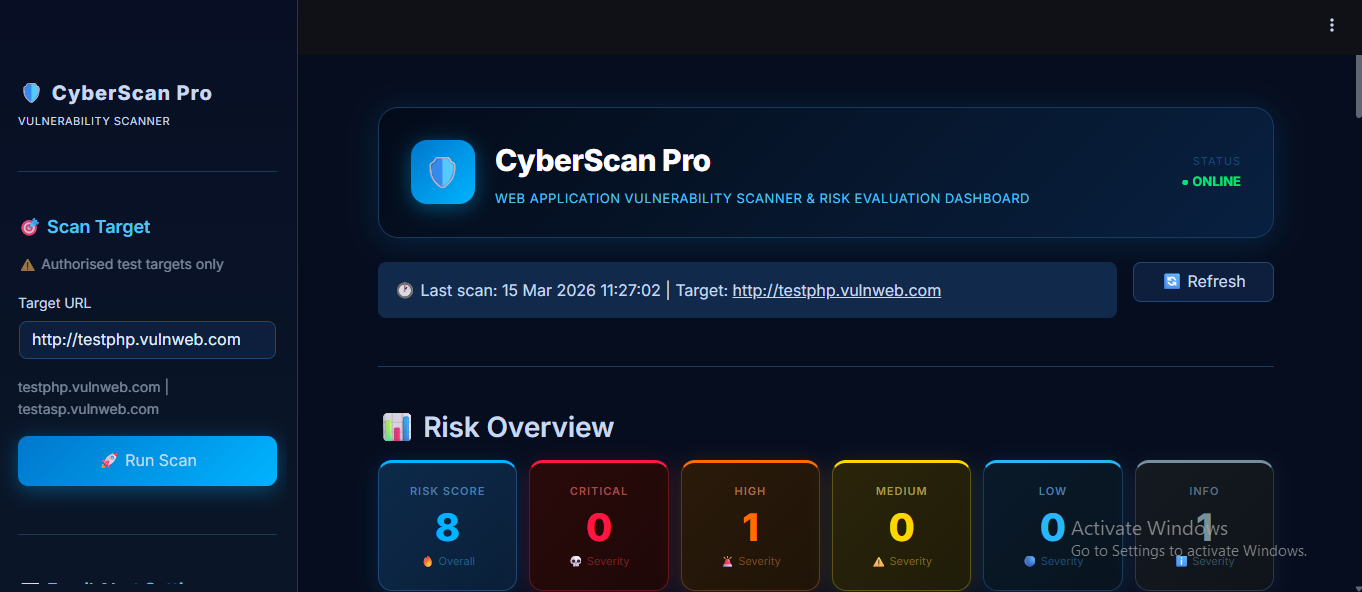

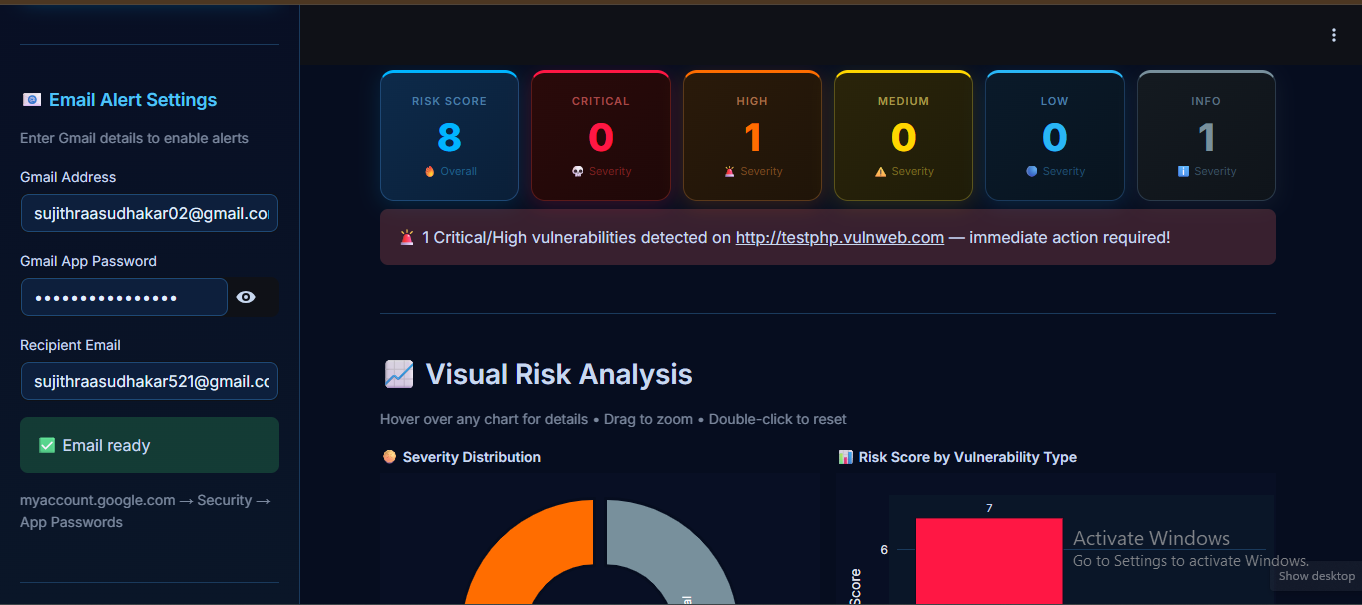

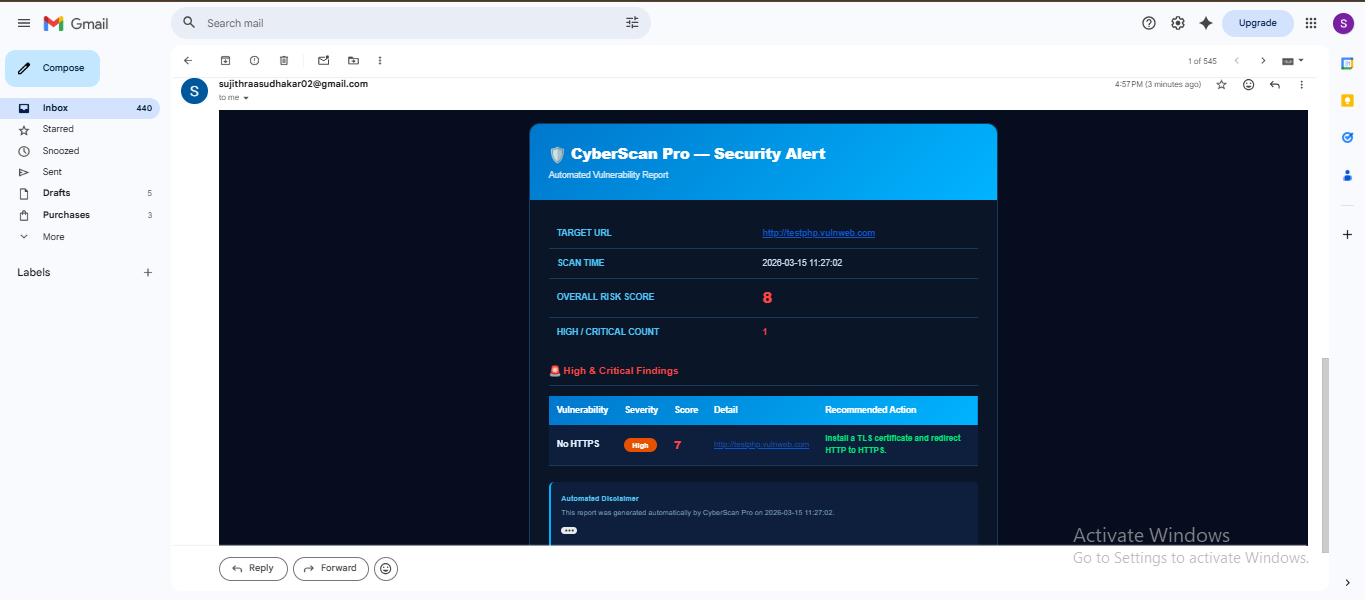

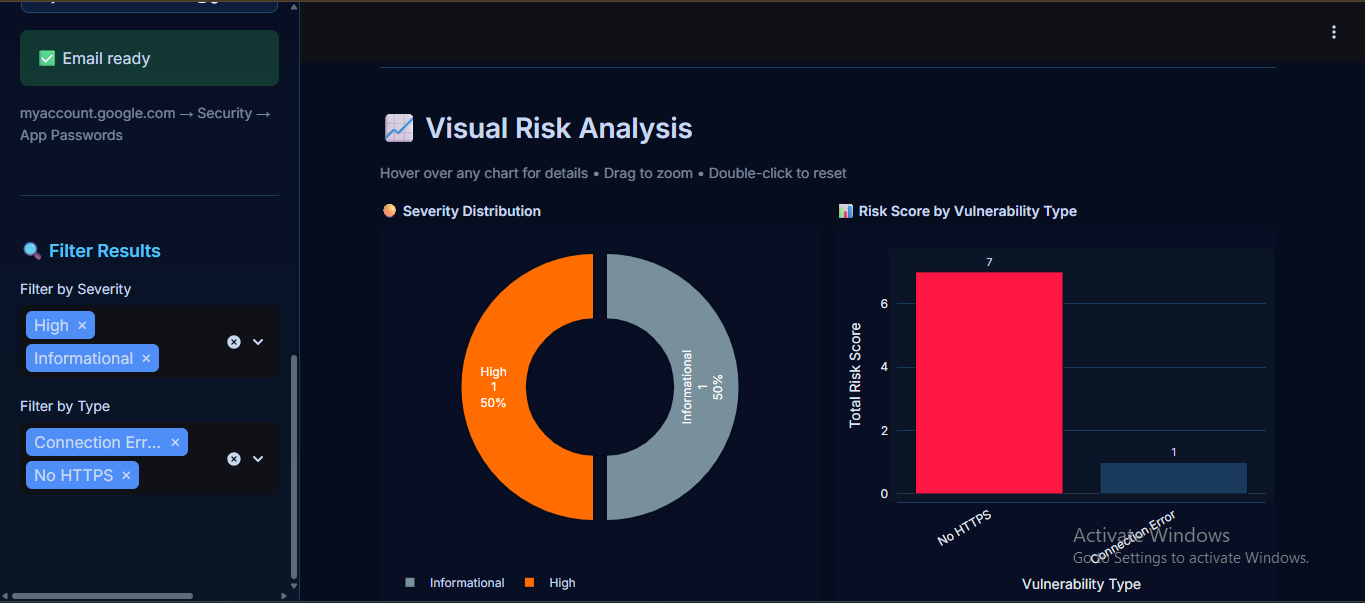

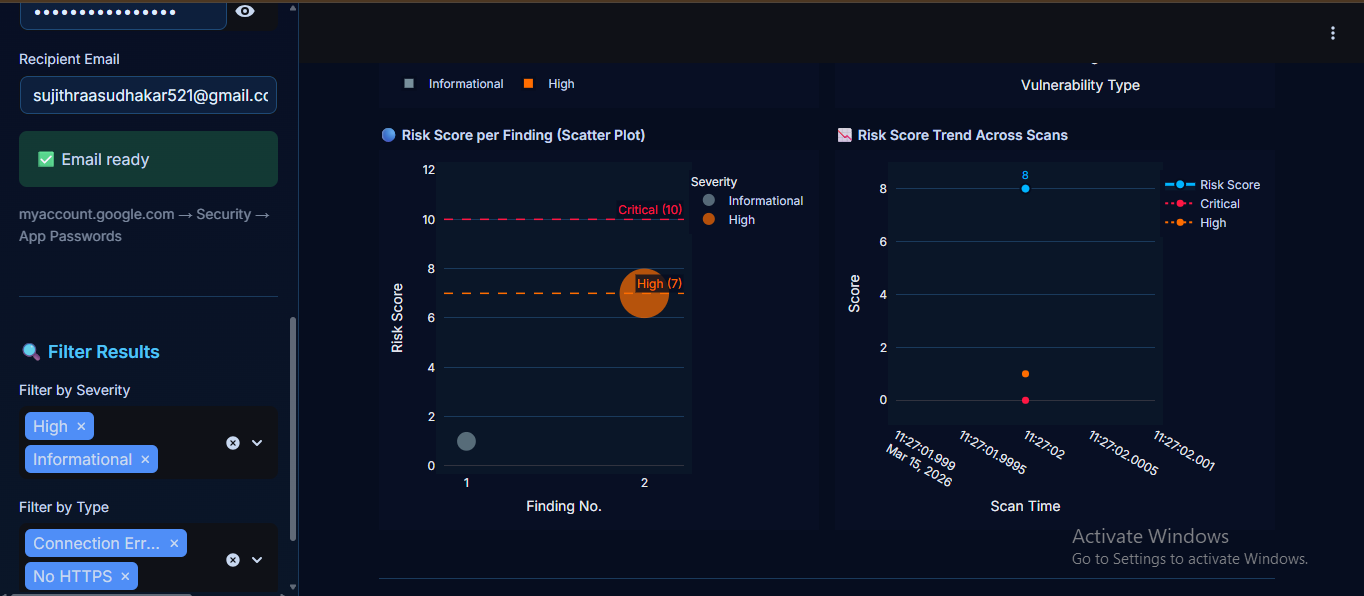

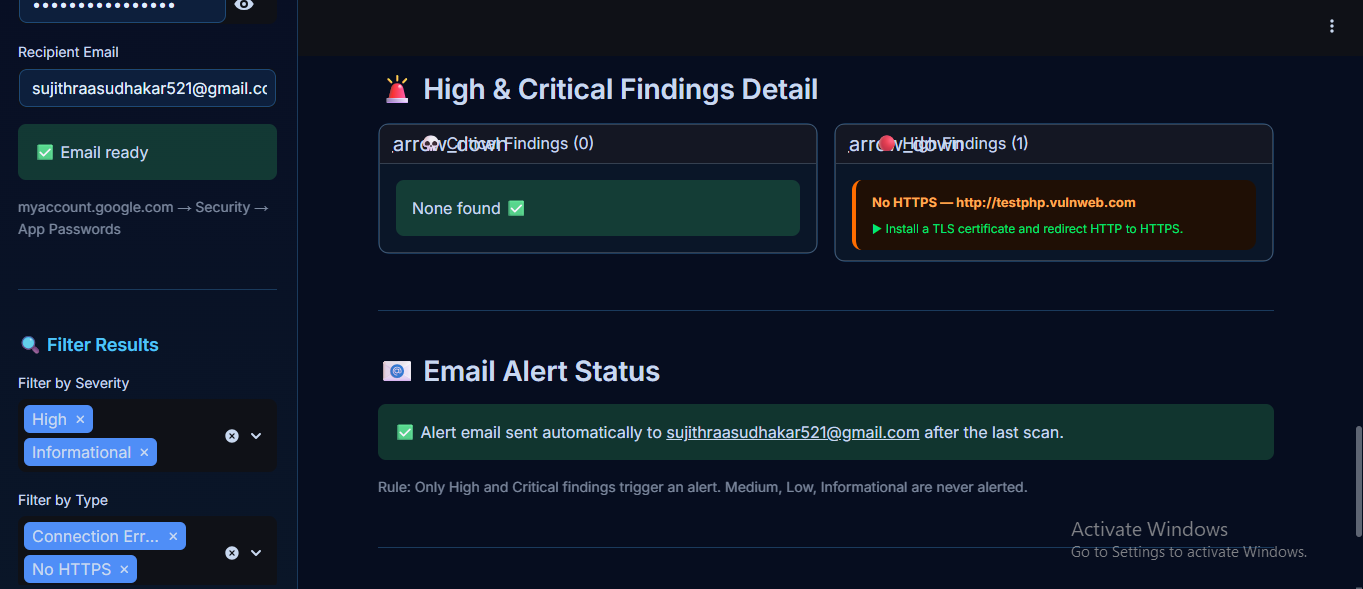